# Random Forest Genre Classifier for FMA Small or Medium

This notebook builds a random forest genre classifier using the precomputed tabular audio features in `fma_metadata/features.csv` joined onto the cleaned per-split CSVs produced by [data_preprocessing.ipynb](data_preprocessing.ipynb).

The `SUBSET` value selects `"small"` (≈8 000 tracks, 8 genres) or `"medium"` (≈25 000 tracks, 16 genres). Both cleaned CSVs are produced by the preprocessing notebook; only the source data and genre count differ.

Pipeline:

1. Project paths and the chosen subset's per-split CSVs are loaded from `fma_preprocessed/`.
2. Each split is joined onto handcrafted FMA features to build train, validation, and test matrices.
3. Per-genre caps can keep each split smaller and balanced.
4. A random forest is trained over one or more `n_estimators` settings.
5. The checkpoint with the best validation accuracy is saved.
6. The best model is evaluated on the held-out test split.

This notebook expects `fma_preprocessed/` from [data_preprocessing.ipynb](data_preprocessing.ipynb).

## 1. Setup

The random forest pipeline depends on `pandas`, `numpy`, and `scikit-learn`.


In [ ]:
from __future__ import annotations

import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


def _load_dotenv(filename=".env"):
    """Load key=value pairs from a .env file without requiring python-dotenv."""
    import os
    for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        p = base / filename
        if p.exists():
            with open(p) as f:
                for line in f:
                    line = line.strip()
                    if line and not line.startswith("#") and "=" in line:
                        key, _, value = line.partition("=")
                        key = key.strip()
                        value = value.strip().strip('"').strip("'")
                        os.environ.setdefault(key, value)
            print(f"Loaded {p}")
            return
    print("No .env file found — using environment variables / built-in defaults.")

_load_dotenv()

import os

# Cleaned FMA subset used for this random forest run.
# Reads DATASET_SIZE from .env; falls back to "small".
# Random Forest supports both "small" and "medium" — "both" defaults to "medium".
_size_raw = os.environ.get("DATASET_SIZE", "small").lower().strip()
SUBSET = "medium" if _size_raw == "medium" else "small"
if SUBSET not in {"small", "medium"}:
    raise ValueError("SUBSET must be either 'small' or 'medium'.")

# Project paths are resolved from DATASET_DIR (if set) or by walking up from cwd.
PROJECT_CANDIDATES = [Path.cwd(), *Path.cwd().parents]
if "DATASET_DIR" in os.environ:
    PROJECT_CANDIDATES.insert(0, Path(os.environ["DATASET_DIR"]))

for candidate in PROJECT_CANDIDATES:
    features_path = candidate / "fma_metadata" / "features.csv"
    _preproc = (
        Path(os.environ["PREPROCESSED_DIR"]).resolve()
        if "PREPROCESSED_DIR" in os.environ
        else candidate / "fma_preprocessed"
    )
    if features_path.exists() and _preproc.exists():
        PROJECT_DIR = candidate.resolve()
        FEATURES_PATH = features_path.resolve()
        PREPROCESSED_DIR = _preproc.resolve()
        break
else:
    raise FileNotFoundError(
        "Could not find fma_metadata/features.csv and fma_preprocessed/. "
        "Set DATASET_DIR in your .env file and run data_preprocessing.ipynb first."
    )

RANDOM_FOREST_DIR = PROJECT_DIR / "code" / "random_forest"
RANDOM_FOREST_DIR.mkdir(parents=True, exist_ok=True)

print({
    "SUBSET": SUBSET,
    "PROJECT_DIR": str(PROJECT_DIR),
    "FEATURES_PATH": str(FEATURES_PATH),
    "PREPROCESSED_DIR": str(PREPROCESSED_DIR),
    "RANDOM_FOREST_DIR": str(RANDOM_FOREST_DIR),
})

## 2. Load Preprocessed Splits + Features

Preprocessing has already filtered the subset, removed tracks without genre labels, excluded undecodable MP3s, and dropped the `FAILED` track ids from `creation.ipynb`. This stage loads the cleaned splits and joins the handcrafted features used by the random forest.

In [8]:
def flatten_columns(columns: pd.Index) -> list[str]:
    return ["__".join(str(part) for part in column) for column in columns]


# Handcrafted audio feature columns are flattened into single-level names.
features = pd.read_csv(FEATURES_PATH, index_col=0, header=[0, 1, 2])
features.columns = flatten_columns(features.columns)
features.index = features.index.astype(int)


def load_split(split: str) -> pd.DataFrame:
    """Read the cleaned per-split CSV for the chosen SUBSET and join on the handcrafted features."""
    split_path = PREPROCESSED_DIR / f"tracks_clean_{SUBSET}_{split}.csv"
    if not split_path.exists():
        raise FileNotFoundError(
            f"Missing {split_path}. Run data_preprocessing.ipynb to produce the "
            f"{SUBSET} CSVs."
        )
    frame = pd.read_csv(split_path)
    frame["track_id"] = frame["track_id"].astype(int)
    frame = frame.set_index("track_id")
    return frame.join(features, how="inner")


train_raw = load_split("training")
val_raw = load_split("validation")
test_raw = load_split("test")

# The cleaned splits are combined for a compact dataset summary.
metadata = pd.concat([train_raw, val_raw, test_raw])
metadata.head()

,subset,split,genre,duration,bit_rate,title,artist,audio_path,label,chroma_cens__kurtosis__01,...,tonnetz__std__04,tonnetz__std__05,tonnetz__std__06,zcr__kurtosis__01,zcr__max__01,zcr__mean__01,zcr__median__01,zcr__min__01,zcr__skew__01,zcr__std__01
track_id,,,,,,,,,,,,,,,,,,,,,
2,small,training,Hip-Hop,168,256000,Food,AWOL,/home/lily/acml-project/fma_small/000/000002.mp3,7,7.180653,...,0.054125,0.012226,0.012111,5.758890,0.459473,0.085629,0.071289,0.0,2.089872,0.061448
3,medium,training,Hip-Hop,237,256000,Electric Ave,AWOL,/home/lily/acml-project/fma_small/000/000003.mp3,7,1.888963,...,0.063831,0.014212,0.017740,2.824694,0.466309,0.084578,0.063965,0.0,1.716724,0.069330
5,small,training,Hip-Hop,206,256000,This World,AWOL,/home/lily/acml-project/fma_small/000/000005.mp3,7,0.527563,...,0.040730,0.012691,0.014759,6.808415,0.375000,0.053114,0.041504,0.0,2.193303,0.044861
10,small,training,Pop,161,192000,Freeway,Kurt Vile,/home/lily/acml-project/fma_small/000/000010.mp3,12,3.702245,...,0.074358,0.017952,0.013921,21.434212,0.452148,0.077515,0.071777,0.0,3.542325,0.040800
134,medium,training,Hip-Hop,207,256000,Street Music,AWOL,/home/lily/acml-project/fma_small/000/000134.mp3,7,0.918445,...,0.058766,0.016322,0.015819,4.731087,0.419434,0.064370,0.050781,0.0,1.806106,0.054623


In [9]:
# Metadata columns are excluded from the random forest feature matrix.
METADATA_COLUMNS = {
    "subset", "split", "genre", "label",
    "duration", "bit_rate", "title", "artist", "audio_path",
}

print(f"Usable rows after preprocessing: {len(metadata):,}")
print(metadata["split"].value_counts())
print(metadata["genre"].value_counts().sort_index())
print(f"Feature columns: {sum(1 for c in metadata.columns if c not in METADATA_COLUMNS)}")

Usable rows after preprocessing: 25,000
split
training      19922
test           2573
validation     2505
Name: count, dtype: int64
genre
Blues                    74
Classical               619
Country                 178
Easy Listening           21
Electronic             6314
Experimental           2251
Folk                   1519
Hip-Hop                2201
Instrumental           1350
International          1018
Jazz                    384
Old-Time / Historic     510
Pop                    1186
Rock                   7103
Soul-RnB                154
Spoken                  118
Name: count, dtype: int64
Feature columns: 518


## 3. Balanced Split Sampling

The splits remain the official FMA splits. Per-genre caps create smaller balanced samples; `None` keeps each split full-sized.

In [10]:
# Per-genre caps define the balanced sample size for each split.
MAX_TRAIN_PER_GENRE = None
MAX_EVAL_PER_GENRE = None


def cap_per_genre(frame: pd.DataFrame, max_per_genre: int | None) -> pd.DataFrame:
    if frame.empty:
        return frame.reset_index(drop=False)
    if max_per_genre is None:
        return frame.sample(frac=1, random_state=SEED).reset_index(drop=False)

    sampled_groups = [
        group.sample(min(len(group), max_per_genre), random_state=SEED)
        for _, group in frame.groupby("genre", sort=False)
    ]
    return (
        pd.concat(sampled_groups)
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=False)
    )


train_df = cap_per_genre(train_raw, MAX_TRAIN_PER_GENRE)
val_df = cap_per_genre(val_raw, MAX_EVAL_PER_GENRE)
test_df = cap_per_genre(test_raw, MAX_EVAL_PER_GENRE)

# Label ids follow the preprocessing mapping, with a train-derived fallback.
genre_map_path = PREPROCESSED_DIR / f"genre_to_idx_{SUBSET}.csv"
if genre_map_path.exists():
    genre_map_df = pd.read_csv(genre_map_path)
    genre_to_idx = dict(zip(genre_map_df["genre"], genre_map_df["label"].astype(int)))
else:
    genres_sorted = sorted(train_df["genre"].unique())
    genre_to_idx = {g: i for i, g in enumerate(genres_sorted)}
idx_to_genre = {idx: genre for genre, idx in genre_to_idx.items()}
genres = [idx_to_genre[i] for i in sorted(idx_to_genre)]

for frame in (train_df, val_df, test_df):
    frame["label"] = frame["genre"].map(genre_to_idx).astype(int)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(genre_to_idx)

Train: 19,922 | Val: 2,505 | Test: 2,573
{'Blues': 0, 'Classical': 1, 'Country': 2, 'Easy Listening': 3, 'Electronic': 4, 'Experimental': 5, 'Folk': 6, 'Hip-Hop': 7, 'Instrumental': 8, 'International': 9, 'Jazz': 10, 'Old-Time / Historic': 11, 'Pop': 12, 'Rock': 13, 'Soul-RnB': 14, 'Spoken': 15}


## 4. Build Tabular Matrices


In [11]:
def split_features_and_labels(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, list[str]]:
    feature_columns = [
        column
        for column in frame.columns
        if column not in METADATA_COLUMNS and column != "track_id"
    ]
    x = frame[feature_columns].to_numpy(dtype=np.float32)
    y = frame["label"].to_numpy(dtype=np.int64)
    return x, y, feature_columns


X_train, y_train, feature_columns = split_features_and_labels(train_df)
X_val, y_val, _ = split_features_and_labels(val_df)
X_test, y_test, _ = split_features_and_labels(test_df)

X_train.shape, X_val.shape, X_test.shape

((19922, 518), (2505, 518), (2573, 518))

## 5. Train the Random Forest

This stage fits the requested forest sizes and keeps the model with the best validation accuracy.

`ccp_alpha` is the direct post-pruning control. `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes` also regularize tree growth during model selection.


In [24]:
# Baseline hyperparameters define the initial validation run.
N_ESTIMATOR_OPTIONS = [250]
MAX_DEPTH = 10
MAX_FEATURES = None
MIN_SAMPLES_SPLIT = 5
MIN_SAMPLES_LEAF = 1
MAX_LEAF_NODES = None
CCP_ALPHA = 0.0

best_val_acc = -1.0
best_model = None
best_n_estimators = None
history = []
best_model_path = RANDOM_FOREST_DIR / f"best_random_forest_{SUBSET}.pkl"

for n_estimators in N_ESTIMATOR_OPTIONS:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=MAX_DEPTH,
        max_features=MAX_FEATURES,
        min_samples_split=MIN_SAMPLES_SPLIT,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_leaf_nodes=MAX_LEAF_NODES,
        ccp_alpha=CCP_ALPHA,
        n_jobs=-1,
        random_state=SEED,
    )
    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    val_predictions = model.predict(X_val)
    train_acc = accuracy_score(y_train, train_predictions)
    val_acc = accuracy_score(y_val, val_predictions)

    history.append({
        "n_estimators": n_estimators,
        "train_acc": train_acc,
        "val_acc": val_acc,
    })

    print(
        f"n_estimators {n_estimators:4d} | "
        f"train acc {train_acc:.3f} | "
        f"val acc {val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model
        best_n_estimators = n_estimators
        with best_model_path.open("wb") as handle:
            pickle.dump({
                "model": best_model,
                "genre_to_idx": genre_to_idx,
                "idx_to_genre": idx_to_genre,
                "feature_columns": feature_columns,
                "config": {
                    "subset": SUBSET,
                    "preprocessed_dir": str(PREPROCESSED_DIR),
                    "max_train_per_genre": MAX_TRAIN_PER_GENRE,
                    "max_eval_per_genre": MAX_EVAL_PER_GENRE,
                    "n_estimators": best_n_estimators,
                    "max_depth": MAX_DEPTH,
                    "max_features": MAX_FEATURES,
                    "min_samples_split": MIN_SAMPLES_SPLIT,
                    "min_samples_leaf": MIN_SAMPLES_LEAF,
                    "max_leaf_nodes": MAX_LEAF_NODES,
                    "ccp_alpha": CCP_ALPHA,
                    "seed": SEED,
                },
                "history": history,
            }, handle)

pd.DataFrame(history)

n_estimators  250 | train acc 0.774 | val acc 0.624


,n_estimators,train_acc,val_acc
0,250,0.773717,0.623553


## 5b. Hyperparameter Tuning

The sweep evaluates each random forest hyperparameter combination and keeps the configuration with the best validation accuracy. Completed configurations are appended to a JSONL resume log and mirrored to a CSV summary, so reruns continue from the remaining grid entries.

In [12]:
import json
import time
from itertools import product

# The tuning grid enumerates every random forest configuration in the sweep.
PARAM_GRID = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [10, 20, None],
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_leaf_nodes": [None, 256],
    "ccp_alpha": [0.0, 1e-4],
}

# Tuning artifacts are anchored in RANDOM_FOREST_DIR for rerun consistency.
best_model_path = RANDOM_FOREST_DIR / f"best_random_forest_{SUBSET}.pkl"
best_val_acc = globals().get("best_val_acc", -1.0)
best_model = globals().get("best_model", None)
best_n_estimators = globals().get("best_n_estimators", None)
history = globals().get("history", [])
starting_best_val_acc = best_val_acc

tuning_log_path = RANDOM_FOREST_DIR / f"random_forest_tuning_results_{SUBSET}.jsonl"
tuning_results_path = RANDOM_FOREST_DIR / f"random_forest_tuning_results_{SUBSET}.csv"
tuned_model_path = RANDOM_FOREST_DIR / f"best_random_forest_tuned_{SUBSET}.pkl"
tuning_log_path.parent.mkdir(parents=True, exist_ok=True)

sweep_context = {
    "subset": SUBSET,
    "max_train_per_genre": MAX_TRAIN_PER_GENRE,
    "max_eval_per_genre": MAX_EVAL_PER_GENRE,
    "train_rows": int(len(X_train)),
    "val_rows": int(len(X_val)),
    "feature_count": int(len(feature_columns)),
}

param_names = list(PARAM_GRID.keys())
all_params = [dict(zip(param_names, values)) for values in product(*(PARAM_GRID[name] for name in param_names))]


def params_key(params: dict) -> str:
    return json.dumps(params, sort_keys=True)


def read_completed_results(path: Path) -> dict[str, dict]:
    completed_by_key = {}
    ignored_rows = 0
    grid_keys = {params_key(params) for params in all_params}

    if not path.exists():
        return completed_by_key

    with path.open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                print(f"Skipping unreadable tuning log line {line_number} in {path}.")
                ignored_rows += 1
                continue

            required_columns = [*param_names, "train_acc", "val_acc"]
            if any(column not in record for column in required_columns):
                ignored_rows += 1
                continue
            if record.get("sweep_context") != sweep_context:
                ignored_rows += 1
                continue

            params = {name: record[name] for name in param_names}
            key = params_key(params)
            if key not in grid_keys:
                ignored_rows += 1
                continue

            record["train_acc"] = float(record["train_acc"])
            record["val_acc"] = float(record["val_acc"])
            completed_by_key[key] = record

    if ignored_rows:
        print(f"Ignored {ignored_rows} saved tuning row(s) that do not match the current grid.")
    return completed_by_key


def write_tuning_snapshot(records: list[dict]) -> pd.DataFrame:
    columns = [
        *param_names,
        "train_acc",
        "val_acc",
        "fit_seconds",
        "completed_at",
        "grid_index",
        "grid_total",
    ]

    if records:
        frame = pd.DataFrame(records)
        for column in columns:
            if column not in frame.columns:
                frame[column] = None
        frame = frame[columns].sort_values("val_acc", ascending=False).reset_index(drop=True)
    else:
        frame = pd.DataFrame(columns=columns)

    frame.to_csv(tuning_results_path, index=False)
    return frame


def checkpoint_payload(model: RandomForestClassifier, params: dict, val_acc: float, records: list[dict]) -> dict:
    return {
        "model": model,
        "genre_to_idx": genre_to_idx,
        "idx_to_genre": idx_to_genre,
        "feature_columns": feature_columns,
        "config": {
            "subset": SUBSET,
            "preprocessed_dir": str(PREPROCESSED_DIR),
            "max_train_per_genre": MAX_TRAIN_PER_GENRE,
            "max_eval_per_genre": MAX_EVAL_PER_GENRE,
            **params,
            "seed": SEED,
        },
        "history": history,
        "tuning_history": records,
        "tuned_val_acc": float(val_acc),
        "tuning_log_path": str(tuning_log_path),
        "tuning_results_path": str(tuning_results_path),
    }


def save_checkpoint(path: Path, model: RandomForestClassifier, params: dict, val_acc: float, records: list[dict]) -> None:
    with path.open("wb") as handle:
        pickle.dump(checkpoint_payload(model, params, val_acc, records), handle)


def checkpoint_matches_params(checkpoint: dict, params: dict) -> bool:
    config = checkpoint.get("config", {})
    return all(config.get(name) == value for name, value in params.items())


def promote_or_retrain_best(params: dict, val_acc: float, records: list[dict]) -> None:
    global best_model, best_val_acc, best_n_estimators

    checkpoint = None
    if tuned_model_path.exists():
        try:
            with tuned_model_path.open("rb") as handle:
                loaded_checkpoint = pickle.load(handle)
            if checkpoint_matches_params(loaded_checkpoint, params):
                checkpoint = loaded_checkpoint
            else:
                print(f"Saved tuned checkpoint at {tuned_model_path} does not match the current best params.")
        except Exception as exc:
            print(f"Could not load {tuned_model_path}: {exc}. Retraining the best params.")

    if checkpoint is None:
        print("Retraining the best saved tuning configuration so it can be promoted.")
        model = RandomForestClassifier(**params, n_jobs=-1, random_state=SEED)
        model.fit(X_train, y_train)
        save_checkpoint(tuned_model_path, model, params, val_acc, records)
        checkpoint = checkpoint_payload(model, params, val_acc, records)

    checkpoint["history"] = history
    checkpoint["tuning_history"] = records
    checkpoint["tuning_log_path"] = str(tuning_log_path)
    checkpoint["tuning_results_path"] = str(tuning_results_path)

    with best_model_path.open("wb") as handle:
        pickle.dump(checkpoint, handle)

    best_model = checkpoint["model"]
    best_val_acc = float(val_acc)
    best_n_estimators = params["n_estimators"]


completed_by_key = read_completed_results(tuning_log_path)
tuning_history = [completed_by_key[params_key(params)] for params in all_params if params_key(params) in completed_by_key]
completed_keys = set(completed_by_key)
tuning_results = write_tuning_snapshot(tuning_history)

print(f"Loaded {len(tuning_history)} completed configuration(s) from {tuning_log_path}.")
print(f"Running {len(all_params) - len(completed_keys)} remaining of {len(all_params)} configuration(s).")
print(f"CSV summary: {tuning_results_path}")

if tuning_history:
    best_record = max(tuning_history, key=lambda record: record["val_acc"])
    tuned_best_val_acc = float(best_record["val_acc"])
    tuned_best_params = {name: best_record[name] for name in param_names}
else:
    tuned_best_val_acc = -1.0
    tuned_best_params = None

for idx, params in enumerate(all_params, start=1):
    key = params_key(params)
    if key in completed_keys:
        continue

    model = RandomForestClassifier(
        **params,
        n_jobs=-1,
        random_state=SEED,
    )

    started_at = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started_at

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    record = {
        **params,
        "train_acc": float(train_acc),
        "val_acc": float(val_acc),
        "fit_seconds": round(fit_seconds, 3),
        "completed_at": pd.Timestamp.now().isoformat(),
        "grid_index": idx,
        "grid_total": len(all_params),
        "sweep_context": sweep_context,
    }
    candidate_history = [*tuning_history, record]

    if val_acc > tuned_best_val_acc:
        tuned_best_val_acc = float(val_acc)
        tuned_best_params = params
        save_checkpoint(tuned_model_path, model, params, val_acc, candidate_history)

    if val_acc > best_val_acc:
        save_checkpoint(best_model_path, model, params, val_acc, candidate_history)
        best_model = model
        best_val_acc = float(val_acc)
        best_n_estimators = params["n_estimators"]

    with tuning_log_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record, sort_keys=True) + "\n")

    tuning_history.append(record)
    completed_keys.add(key)
    tuning_results = write_tuning_snapshot(tuning_history)

    print(
        f"[{idx:3d}/{len(all_params)}] "
        + " ".join(f"{name}={params[name]}" for name in param_names)
        + f" | train {train_acc:.3f} | val {val_acc:.3f} | saved"
    )

if not tuning_history:
    print("No tuning configurations have completed yet.")
else:
    best_record = max(tuning_history, key=lambda record: record["val_acc"])
    tuned_best_val_acc = float(best_record["val_acc"])
    tuned_best_params = {name: best_record[name] for name in param_names}

    if tuned_best_val_acc > best_val_acc:
        promote_or_retrain_best(tuned_best_params, tuned_best_val_acc, tuning_history)

    print("\nBest configuration from sweep:")
    for name, value in tuned_best_params.items():
        print(f"  {name}: {value}")
    print(f"  validation accuracy: {tuned_best_val_acc:.3f}")

    if tuned_best_val_acc > starting_best_val_acc:
        print(f"\nBest tuned model improves val acc {starting_best_val_acc:.3f} -> {tuned_best_val_acc:.3f}.")
        print(f"Best model checkpoint: {best_model_path}")
    else:
        print(f"\nNo tuned model beat the existing best ({starting_best_val_acc:.3f}); checkpoint unchanged.")

    print(f"Resume log: {tuning_log_path}")
    print(f"CSV summary: {tuning_results_path}")

tuning_results.head(10)

Loaded 1296 completed configuration(s) from /home/lily/acml-project/code/random_forest/random_forest_tuning_results_medium.jsonl.
Running 0 remaining of 1296 configuration(s).
CSV summary: /home/lily/acml-project/code/random_forest/random_forest_tuning_results_medium.csv

Best configuration from sweep:
  n_estimators: 400
  max_depth: None
  max_features: None
  min_samples_split: 2
  min_samples_leaf: 1
  max_leaf_nodes: None
  ccp_alpha: 0.0
  validation accuracy: 0.636

Best tuned model improves val acc -1.000 -> 0.636.
Best model checkpoint: /home/lily/acml-project/code/random_forest/best_random_forest_medium.pkl
Resume log: /home/lily/acml-project/code/random_forest/random_forest_tuning_results_medium.jsonl
CSV summary: /home/lily/acml-project/code/random_forest/random_forest_tuning_results_medium.csv


,n_estimators,max_depth,max_features,min_samples_split,min_samples_leaf,max_leaf_nodes,ccp_alpha,train_acc,val_acc,fit_seconds,completed_at,grid_index,grid_total
0,400,NaN,None,2,1,NaN,0.0000,0.999799,0.636327,324.334,2026-05-19T08:08:37.921945,1261,1296
1,200,20.0,None,2,2,NaN,0.0000,0.980725,0.635529,115.689,2026-05-18T21:28:05.900444,509,1296
2,200,NaN,None,10,1,NaN,0.0000,0.986598,0.634731,163.239,2026-05-18T23:12:47.247730,637,1296
3,300,20.0,None,2,2,NaN,0.0000,0.980825,0.634331,170.559,2026-05-19T01:06:43.292428,833,1296
4,200,NaN,None,2,2,NaN,0.0000,0.994930,0.634331,152.443,2026-05-18T22:33:57.451214,617,1296
5,200,20.0,None,2,2,NaN,0.0001,0.972242,0.633932,115.720,2026-05-18T21:30:02.104176,510,1296
6,400,20.0,None,2,2,NaN,0.0000,0.980825,0.633134,225.321,2026-05-19T06:15:37.531480,1157,1296
7,200,NaN,None,10,1,NaN,0.0001,0.962805,0.633134,162.498,2026-05-18T23:15:29.832512,638,1296
8,300,20.0,None,2,2,NaN,0.0001,0.972844,0.632735,170.210,2026-05-19T01:09:33.617163,834,1296
9,400,20.0,None,2,2,NaN,0.0001,0.973547,0.632735,225.118,2026-05-19T06:19:22.800480,1158,1296


## 6. Test Evaluation


In [13]:
# The best validation checkpoint is reloaded for final test evaluation.
with best_model_path.open("rb") as handle:
    checkpoint = pickle.load(handle)

best_model = checkpoint["model"]
test_predictions = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_predictions)

print(f"Best validation accuracy: {best_val_acc:.3f} at n_estimators={best_n_estimators}")
print(f"Test accuracy: {test_acc:.3f}")


Best validation accuracy: 0.636 at n_estimators=400
Test accuracy: 0.590


## 7. Inspect Predictions


In [14]:
pd.DataFrame({
    "true": [idx_to_genre[int(label)] for label in y_test[:16]],
    "predicted": [idx_to_genre[int(prediction)] for prediction in test_predictions[:16]],
})


,true,predicted
0,Rock,Electronic
1,Hip-Hop,Hip-Hop
2,Electronic,Electronic
3,Hip-Hop,Hip-Hop
4,Classical,Instrumental
5,Experimental,Experimental
6,Electronic,Electronic
7,Electronic,Electronic
8,Rock,Rock
9,Rock,Rock


In [15]:
print("Classification report:")
print(classification_report(y_test, test_predictions, target_names=genres, digits=3))

confusion = confusion_matrix(y_test, test_predictions)
confusion_df = pd.DataFrame(confusion, index=genres, columns=genres)
confusion_df


Classification report:
                     precision    recall  f1-score   support

              Blues      0.000     0.000     0.000         8
          Classical      0.672     0.661     0.667        62
            Country      0.000     0.000     0.000        18
     Easy Listening      0.000     0.000     0.000         6
         Electronic      0.562     0.866     0.682       632
       Experimental      0.356     0.253     0.296       225
               Folk      0.311     0.270     0.289       152
            Hip-Hop      0.798     0.468     0.590       220
       Instrumental      0.421     0.230     0.297       174
      International      0.667     0.216     0.326       102
               Jazz      0.750     0.077     0.140        39
Old-Time / Historic      0.817     0.961     0.883        51
                Pop      0.000     0.000     0.000       119
               Rock      0.668     0.866     0.754       711
           Soul-RnB      0.000     0.000     0.000        42


/home/lily/acml-project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lily/acml-project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lily/acml-project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

,Blues,Classical,Country,Easy Listening,Electronic,Experimental,Folk,Hip-Hop,Instrumental,International,Jazz,Old-Time / Historic,Pop,Rock,Soul-RnB,Spoken
Blues,0,0,0,0,2,1,1,1,0,0,0,0,0,3,0,0
Classical,0,41,0,0,5,6,1,0,8,0,0,1,0,0,0,0
Country,0,0,0,0,4,0,0,2,0,0,0,0,0,12,0,0
Easy Listening,0,0,0,0,1,1,0,0,4,0,0,0,0,0,0,0
Electronic,0,2,0,0,547,26,1,7,10,0,0,1,0,38,0,0
Experimental,0,4,0,0,66,57,18,3,15,2,1,0,0,59,0,0
Folk,0,0,0,0,15,16,41,0,7,4,0,4,1,64,0,0
Hip-Hop,0,0,0,0,101,6,0,103,1,1,0,0,1,7,0,0
Instrumental,0,11,0,0,25,22,35,0,40,2,0,5,0,34,0,0
International,0,0,0,0,23,4,16,3,1,22,0,0,0,32,0,1


Saved confusion matrix to /home/lily/acml-project/code/random_forest/confusion_matrix_random_forest_medium.png


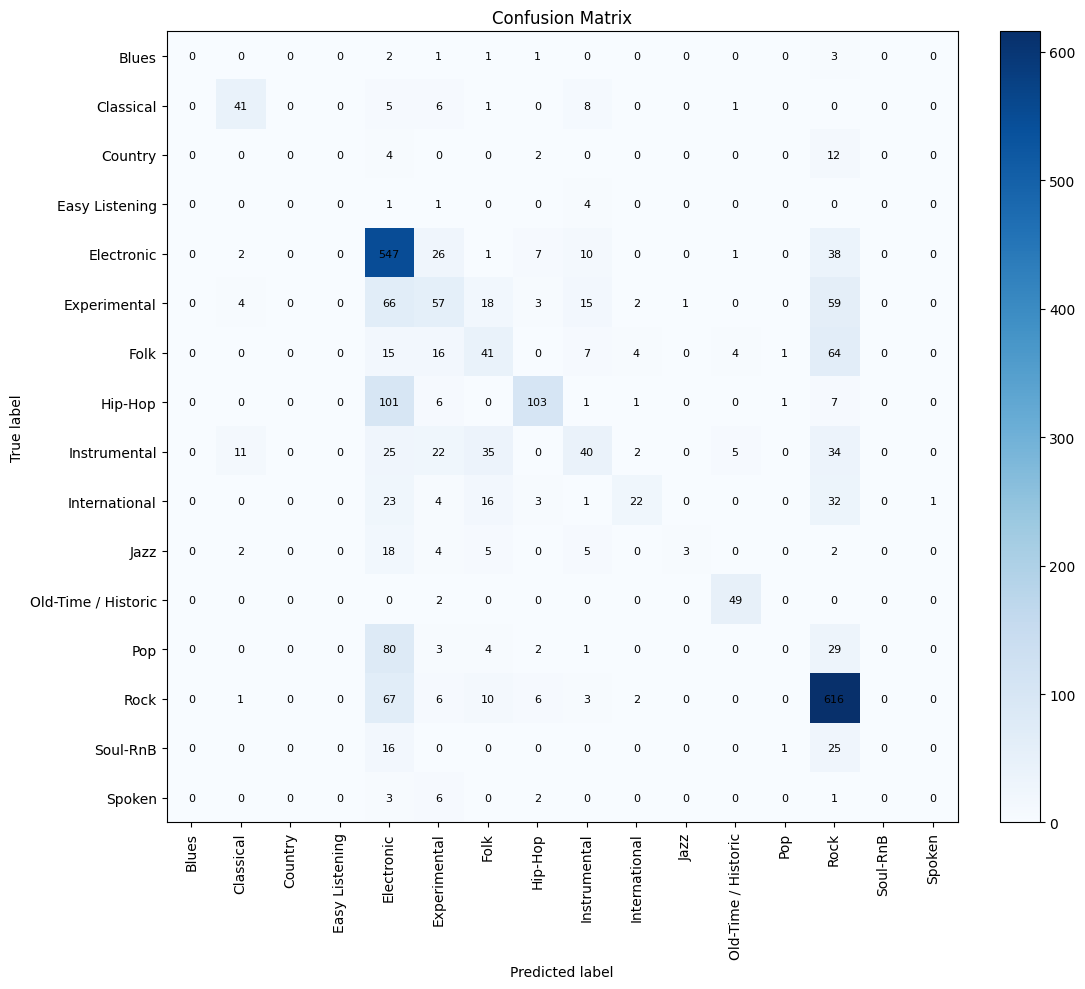

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(confusion, cmap="Blues")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(len(genres)))
ax.set_yticks(range(len(genres)))
ax.set_xticklabels(genres, rotation=90)
ax.set_yticklabels(genres)

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax.text(j, i, confusion[i, j], ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
confusion_matrix_path = RANDOM_FOREST_DIR / f"confusion_matrix_random_forest_{SUBSET}.png"
fig.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
print(f"Saved confusion matrix to {confusion_matrix_path}")
plt.show()
